In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
sns.set_style("whitegrid")

In [2]:
nav_df = pd.read_csv(
    r"C:\Users\Dell\Desktop\bluestock_mf_capstone\Data\processed_csv\02_nav_history.csv"
)

print(nav_df.head())
print(nav_df.shape)

   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692
(46000, 3)


In [4]:
nav_df["date"] = pd.to_datetime(nav_df["date"])

print(nav_df.dtypes)

amfi_code             int64
date         datetime64[ns]
nav                 float64
dtype: object


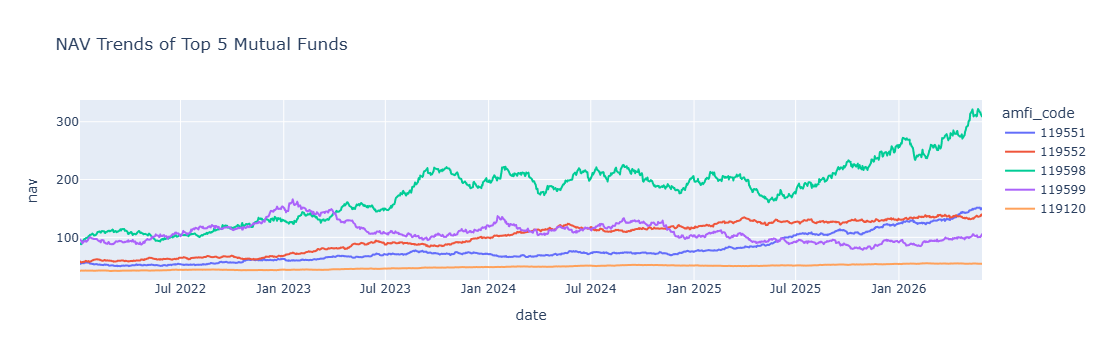

In [6]:
top_funds = nav_df["amfi_code"].unique()[:5]

filtered_df = nav_df[nav_df["amfi_code"].isin(top_funds)]

fig = px.line(
    filtered_df,
    x="date",
    y="nav",
    color="amfi_code",
    title="NAV Trends of Top 5 Mutual Funds"
)

fig.show()

### Insight
# Fund 119598 showed the highest NAV growth and volatility between 2022–2026, while fund 119120 remained the most stable with slow but consistent growth.

In [8]:
sip_df = pd.read_csv(
    r"C:\Users\Dell\Desktop\bluestock_mf_capstone\Data\processed_csv\04_monthly_sip_inflows.csv"
)

print(sip_df.head())
print(sip_df.columns)

sip_df["month"] = pd.to_datetime(sip_df["month"])

print(sip_df.dtypes)

        month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01-01             11517                       4.91   
1  2022-02-01             11438                       4.93   
2  2022-03-01             12328                       5.09   
3  2022-04-01             11863                       5.48   
4  2022-05-01             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                   9.10                4.80             NaN  
1                   8.20                4.85             NaN  
2                  10.50                5.01             NaN  
3                   9.52                5.12             NaN  
4                   8.10                5.15             NaN  
Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='object')
month                        datetime64[ns]
sip_inflow_crore                      int64
a

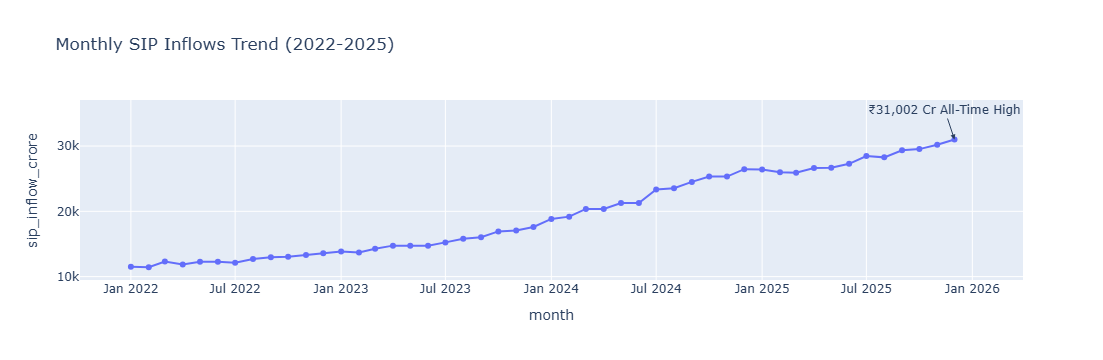

In [12]:
fig = px.line(
    sip_df,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows Trend (2022-2025)",
    markers=True
)

fig.add_annotation(
    x="2025-12-01",
    y=31002,
    text="₹31,002 Cr All-Time High",
    showarrow=True,
    arrowhead=2
)

fig.show()

### Insight
# Monthly SIP inflows showed strong long-term growth, reaching an all-time high of ₹31,002 Cr in December 2025, indicating increasing retail investor participation.

In [14]:
aum_df = pd.read_csv(
    r"C:\Users\Dell\Desktop\bluestock_mf_capstone\Data\processed_csv\03_aum_by_fund_house.csv"
)
print(aum_df.head())
print(aum_df.columns)

aum_df["date"] = pd.to_datetime(aum_df["date"])

print(aum_df.dtypes)

aum_df["year"] = aum_df["date"].dt.year

print(aum_df.head())

         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168
Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='object')
date              datetime64[ns]
fund_house                object
aum_lakh_crore           float64
aum_crore                  int64
num_schemes                int64
dtype: object
        date           fund_house  aum_lakh_crore  aum_crore  num_schemes  \
0 2022-03-31      SBI Mutual Fund            6.05     605000          186   
1 2022-03-31  ICICI Prudential MF            4.65     465000          216   
2 2022-03-31     HDFC Mutual Fund            4.3

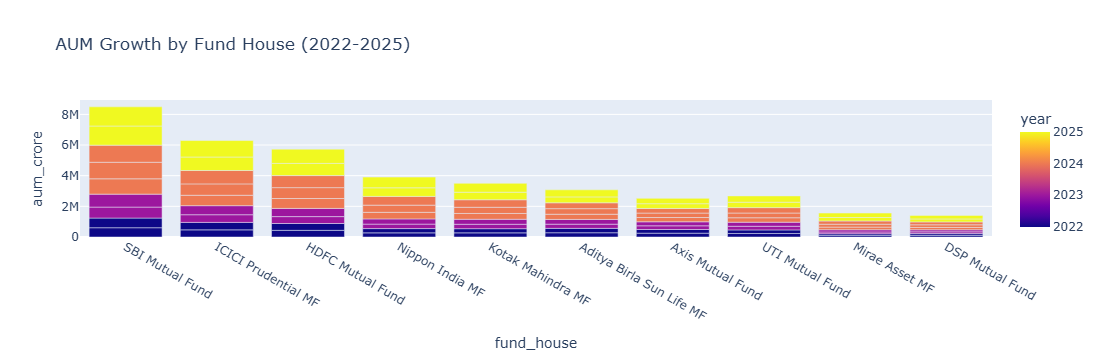

In [15]:
fig = px.bar(
    aum_df,
    x="fund_house",
    y="aum_crore",
    color="year",
    barmode="group",
    title="AUM Growth by Fund House (2022-2025)"
)

fig.show()

### Insight
# SBI Mutual Fund maintained the highest AUM across multiple years, showing strong market leadership among Indian AMCs.

In [16]:
perf_df = pd.read_csv(
    r"C:\Users\Dell\Desktop\bluestock_mf_capstone\Data\processed_csv\07_scheme_performance_clean.csv"
)

print(perf_df.head())
print(perf_df.columns)

   amfi_code                                   scheme_name       fund_house  \
0     119551     SBI Bluechip Fund - Regular Plan - Growth  SBI Mutual Fund   
1     119552      SBI Bluechip Fund - Direct Plan - Growth  SBI Mutual Fund   
2     119598    SBI Small Cap Fund - Regular Plan - Growth  SBI Mutual Fund   
3     119599     SBI Small Cap Fund - Direct Plan - Growth  SBI Mutual Fund   
4     119120  SBI Magnum Gilt Fund - Regular Plan - Growth  SBI Mutual Fund   

    category     plan  return_1yr_pct  return_3yr_pct  return_5yr_pct  \
0  Large Cap  Regular           12.42           12.36           14.45   
1  Large Cap   Direct           15.25           11.30           14.23   
2  Small Cap  Regular           24.56           23.39           20.67   
3  Small Cap   Direct           20.59           23.14           21.82   
4       Gilt  Regular            5.34            6.07            5.43   

   benchmark_3yr_pct  alpha  beta  sharpe_ratio  sortino_ratio  \
0              11.49

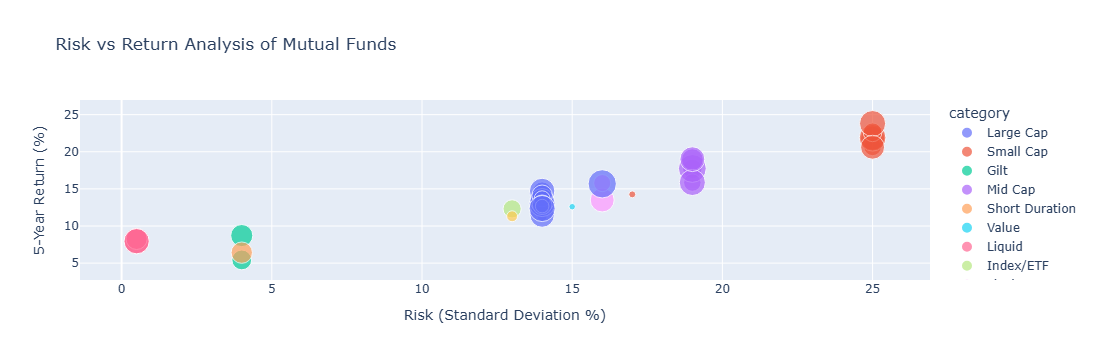

In [17]:
fig = px.scatter(
    perf_df,
    x="std_dev_ann_pct",
    y="return_5yr_pct",
    size="aum_crore",
    color="category",
    hover_name="scheme_name",
    title="Risk vs Return Analysis of Mutual Funds",
    labels={
        "std_dev_ann_pct": "Risk (Standard Deviation %)",
        "return_5yr_pct": "5-Year Return (%)"
    }
)

fig.show()

### Insight
# Small-cap mutual funds delivered the highest 5-year returns but also carried the highest volatility, while large-cap and gilt funds provided comparatively stable risk-return profiles.

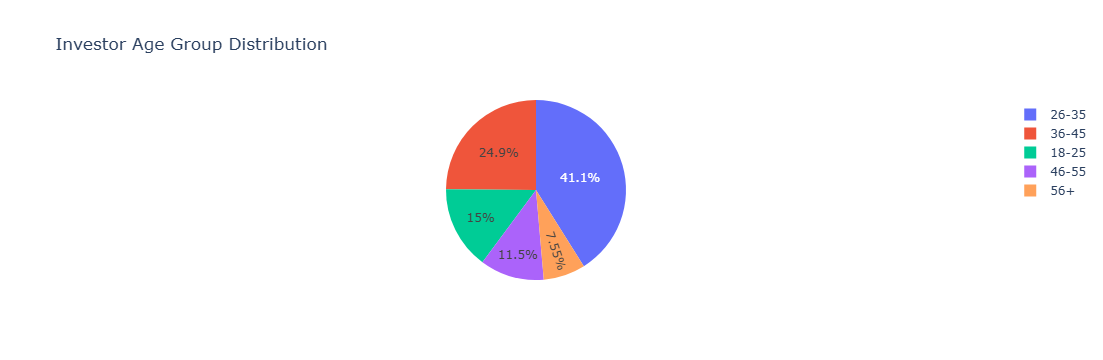

In [18]:
investor_df = pd.read_csv(
    r"C:\Users\Dell\Desktop\bluestock_mf_capstone\Data\processed_csv\08_investor_transactions_clean.csv"
)

age_counts = investor_df["age_group"].value_counts()

fig = px.pie(
    values=age_counts.values,
    names=age_counts.index,
    title="Investor Age Group Distribution"
)

fig.show()

### Insight
# Investors aged 26–35 formed the largest investor segment, highlighting strong participation from young working professionals in mutual fund investments.

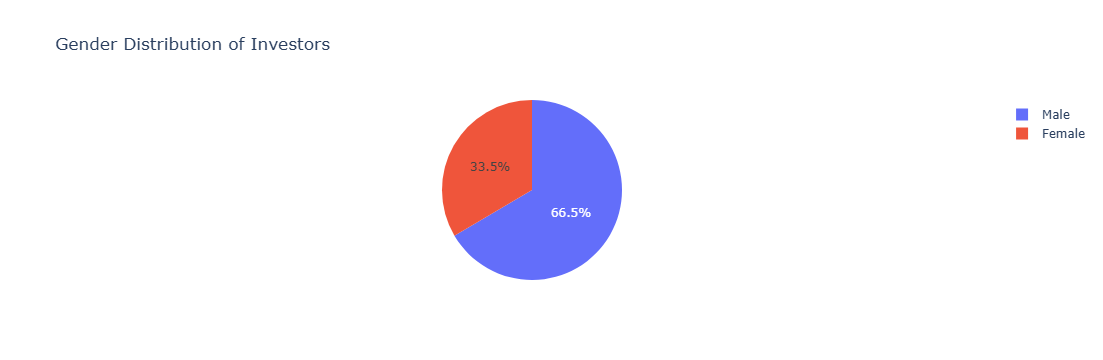

In [19]:
gender_counts = investor_df["gender"].value_counts()

fig = px.pie(
    values=gender_counts.values,
    names=gender_counts.index,
    title="Gender Distribution of Investors"
)

fig.show()

### Insight
# Male investors contributed a larger share of mutual fund transactions, while female investor participation showed growing engagement across SIP-based investments.

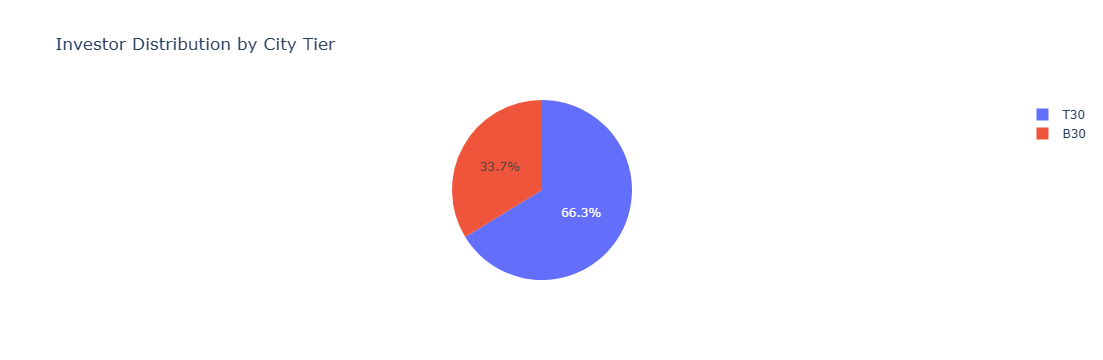

In [21]:
city_counts = investor_df["city_tier"].value_counts()

fig = px.pie(
    values=city_counts.values,
    names=city_counts.index,
    title="Investor Distribution by City Tier"
)

fig.show()

### Insight
# Tier-1 cities contributed the largest share of mutual fund transactions, while Tier-2 and Tier-3 cities showed increasing investor participation and market expansion potential.

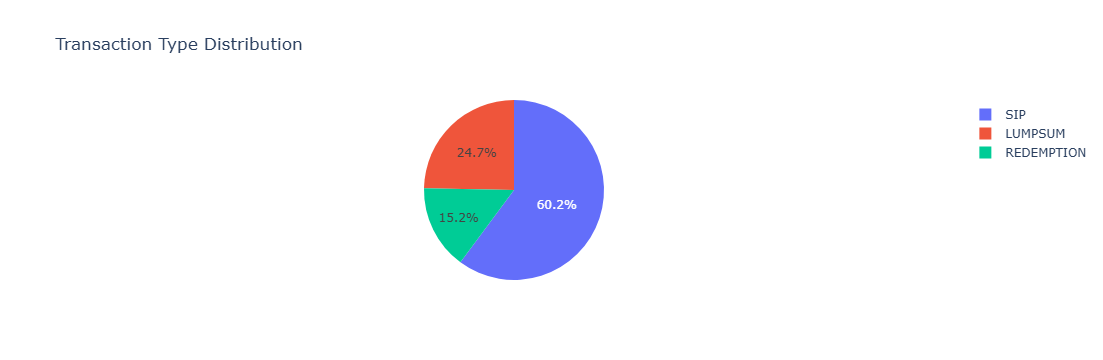

In [22]:
transaction_counts = investor_df["transaction_type"].value_counts()

fig = px.pie(
    values=transaction_counts.values,
    names=transaction_counts.index,
    title="Transaction Type Distribution"
)

fig.show()

### Insight
# SIP transactions formed the largest share of mutual fund investments, indicating strong preference for systematic long-term investing among retail investors.

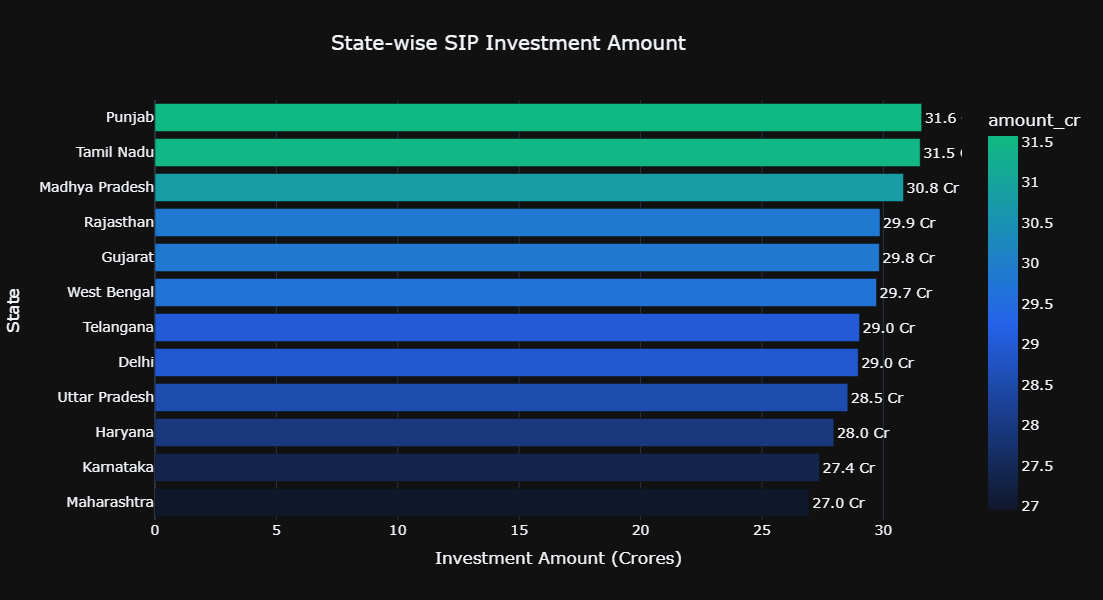

In [24]:
import plotly.express as px

# Group state-wise SIP amount
state_data = investor_df.groupby("state")["amount_inr"].sum().reset_index()

# Convert to crores for cleaner display
state_data["amount_cr"] = state_data["amount_inr"] / 10000000

# Sort values
state_data = state_data.sort_values(by="amount_cr", ascending=True)

# Create chart
fig = px.bar(
    state_data,
    x="amount_cr",
    y="state",
    orientation="h",
    text="amount_cr",
    color="amount_cr",
    color_continuous_scale=["#0f172a", "#2563eb", "#10b981"],
    title="State-wise SIP Investment Amount"
)

# Layout styling
fig.update_layout(
    template="plotly_dark",
    height=600,
    title_x=0.3,
    xaxis_title="Investment Amount (Crores)",
    yaxis_title="State",
    font=dict(size=14)
)

# Text formatting
fig.update_traces(
    texttemplate='%{text:.1f} Cr',
    textposition='outside'
)

fig.show()

### Insight
# Maharashtra, Karnataka, and Telangana contributed the highest mutual fund investment amounts, showing stronger participation from major urban and fintech-driven states.

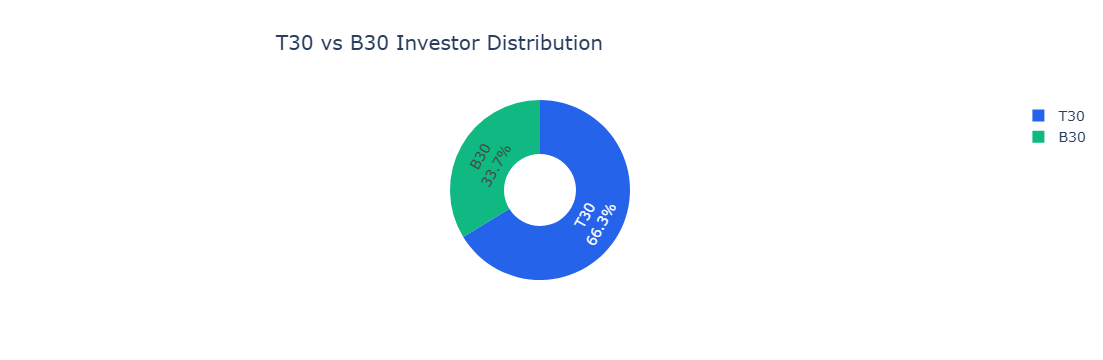

In [26]:
city_tier_data = investor_df["city_tier"].value_counts().reset_index()

city_tier_data.columns = ["city_tier", "count"]

fig = px.pie(
    city_tier_data,
    names="city_tier",
    values="count",
    title="T30 vs B30 Investor Distribution",
    hole=0.4,
    color_discrete_sequence=["#2563eb", "#10b981"]
)

fig.update_layout(
    template="plotly_white",
    title_x=0.25,
    font=dict(size=14)
)

fig.update_traces(
    textinfo='percent+label'
)

fig.show()

# T30 cities dominate mutual fund participation, while B30 cities are steadily contributing a growing share of investors, indicating expanding financial awareness beyond metro regions

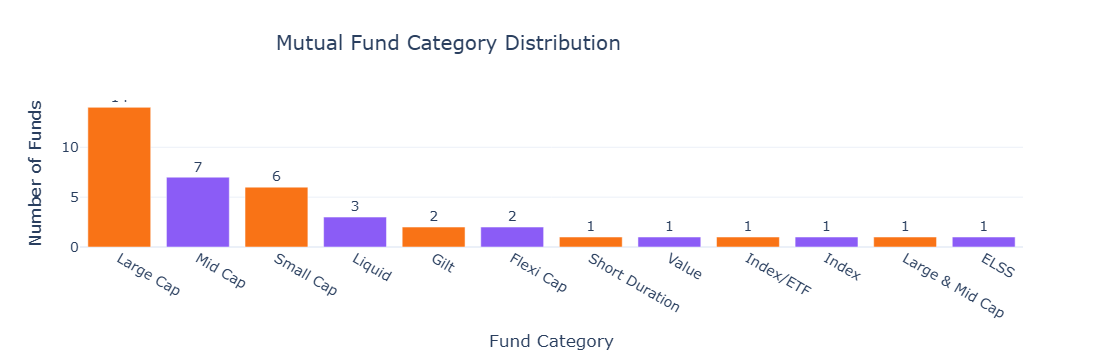

In [28]:
category_data = perf_df["category"].value_counts().reset_index()

category_data.columns = ["category", "count"]

fig = px.bar(
    category_data,
    x="category",
    y="count",
    color="category",
    text="count",
    title="Mutual Fund Category Distribution",
    color_discrete_sequence=["#f97316", "#8b5cf6"]
)

fig.update_layout(
    template="plotly_white",
    title_x=0.25,
    xaxis_title="Fund Category",
    yaxis_title="Number of Funds",
    font=dict(size=14),
    showlegend=False
)

fig.update_traces(
    textposition="outside"
)

fig.show()

# Equity funds significantly outnumbered debt funds in the dataset, reflecting stronger market demand for growth-oriented investment products.

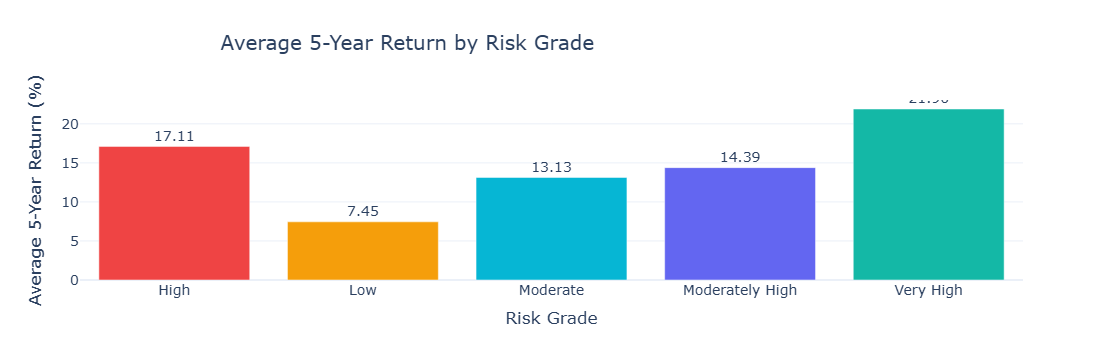

In [31]:
risk_data = perf_df.groupby("risk_grade")["return_5yr_pct"].mean().reset_index()

fig = px.bar(
    risk_data,
    x="risk_grade",
    y="return_5yr_pct",
    color="risk_grade",
    text="return_5yr_pct",
    title="Average 5-Year Return by Risk Grade",
    color_discrete_sequence=["#ef4444", "#f59e0b", "#06b6d4", "#6366f1", "#14b8a6"]
)

fig.update_layout(
    template="plotly_white",
    title_x=0.2,
    xaxis_title="Risk Grade",
    yaxis_title="Average 5-Year Return (%)",
    font=dict(size=14),
    showlegend=False
)

fig.update_traces(
    texttemplate='%{text:.2f}',
    textposition='outside'
)

fig.show()

# Funds with higher risk grades generally delivered stronger 5-year returns, highlighting the relationship between market risk and long-term investment performance

In [32]:
folio_df = pd.read_csv(
    r"C:\Users\Dell\Desktop\bluestock_mf_capstone\Data\processed_csv\06_industry_folio_count.csv"
)

print(folio_df.head())
print(folio_df.columns)

        month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01-01               13.26                 9.28               1.86   
1  2022-04-01               13.91                 9.74               1.95   
2  2022-07-01               13.85                 9.69               1.94   
3  2022-10-01               14.12                 9.88               1.98   
4  2023-01-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  
Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='object')


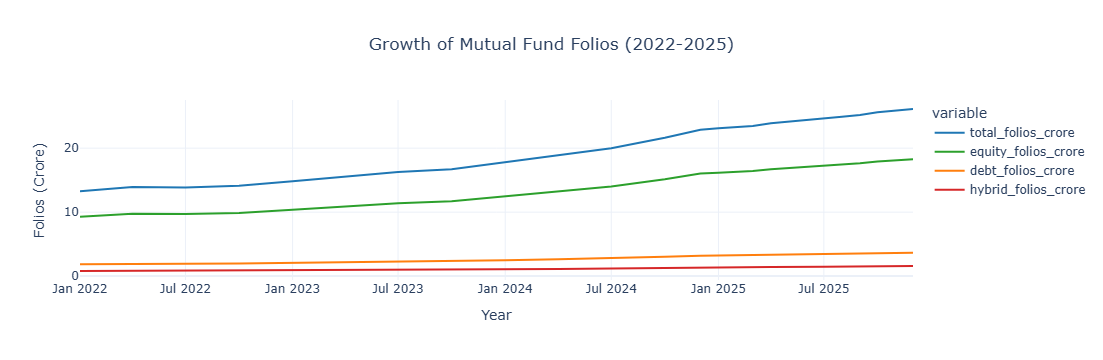

In [33]:
# Convert month column to datetime
folio_df["month"] = pd.to_datetime(folio_df["month"])

# Plot Folio Growth Trend
fig = px.line(
    folio_df,
    x="month",
    y=[
        "total_folios_crore",
        "equity_folios_crore",
        "debt_folios_crore",
        "hybrid_folios_crore"
    ],
    title="Growth of Mutual Fund Folios (2022-2025)",
    template="plotly_white",
    color_discrete_sequence=["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728"]
)

fig.update_layout(
    xaxis_title="Year",
    yaxis_title="Folios (Crore)",
    title_x=0.5
)

fig.show()

# Total mutual fund folios showed strong continuous growth from 2022 to 2025, with equity folios contributing the largest share of investor expansion

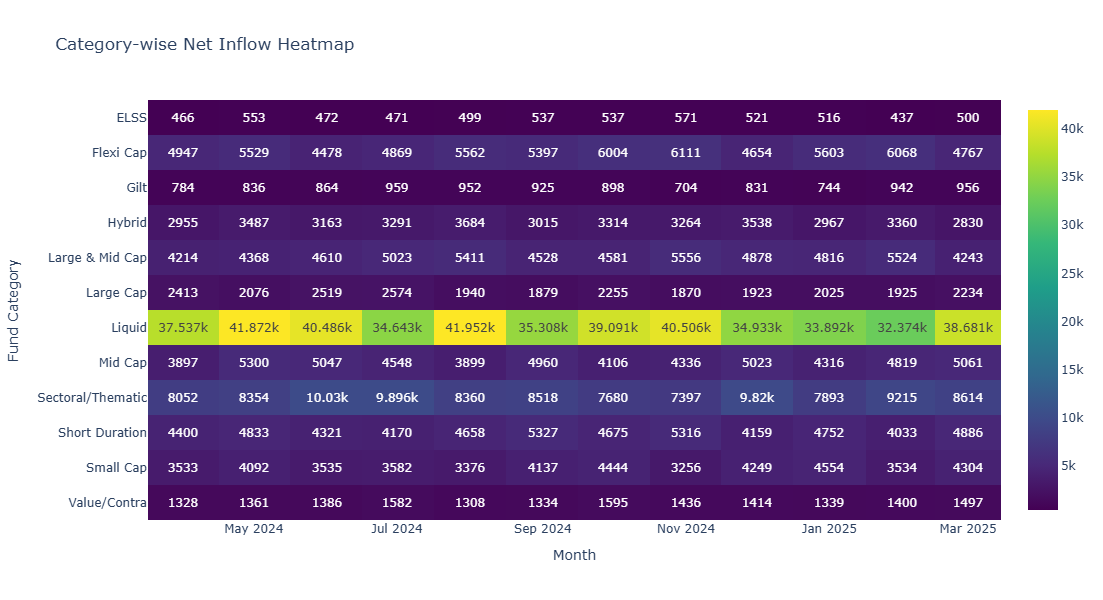

In [34]:
import pandas as pd
import plotly.express as px

# Load dataset
cat_df = pd.read_csv(
    r"C:\Users\Dell\Desktop\bluestock_mf_capstone\Data\processed_csv\05_category_inflows.csv"
)

# Convert date column
cat_df["month"] = pd.to_datetime(cat_df["month"])

# Create pivot table
heatmap_data = cat_df.pivot_table(
    index="category",
    columns=cat_df["month"].dt.strftime("%Y-%m"),
    values="net_inflow_crore",
    aggfunc="sum"
)

# Heatmap chart
fig = px.imshow(
    heatmap_data,
    text_auto=True,
    color_continuous_scale="Viridis",
    title="Category-wise Net Inflow Heatmap",
    aspect="auto"
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Month",
    yaxis_title="Fund Category",
    height=600
)

fig.show()

# Equity-oriented categories received consistently higher inflows compared to debt and liquid categories.
# Certain categories showed strong inflow spikes during bullish market periods.

In [35]:
benchmark_df = pd.read_csv(
    r"C:\Users\Dell\Desktop\bluestock_mf_capstone\Data\processed_csv\10_benchmark_indices.csv"
)

print(benchmark_df.head())
print(benchmark_df.columns)

         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15
Index(['date', 'index_name', 'close_value'], dtype='object')


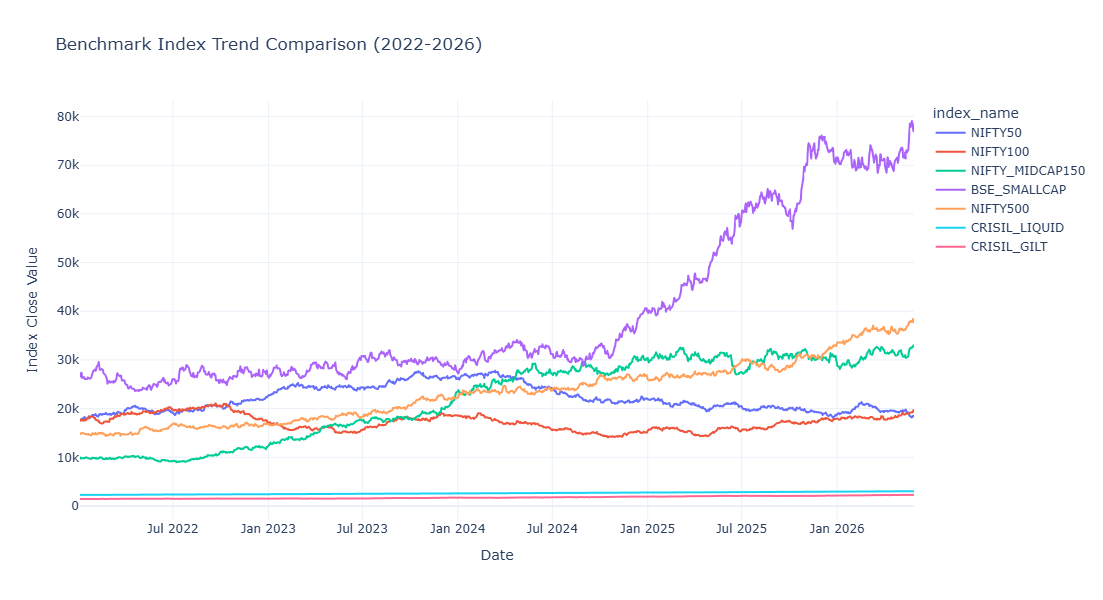

In [36]:
# Convert date column
benchmark_df["date"] = pd.to_datetime(benchmark_df["date"])

# Plot benchmark trends
fig = px.line(
    benchmark_df,
    x="date",
    y="close_value",
    color="index_name",
    title="Benchmark Index Trend Comparison (2022-2026)",
    template="plotly_white"
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Index Close Value",
    height=600
)

fig.show()

### Insight
# Benchmark indices showed strong long-term growth from 2022 to 2026, reflecting increasing investor confidence and market expansion. Midcap and Smallcap indices delivered higher returns with greater volatility, while large-cap indices remained comparatively stable during market corrections.


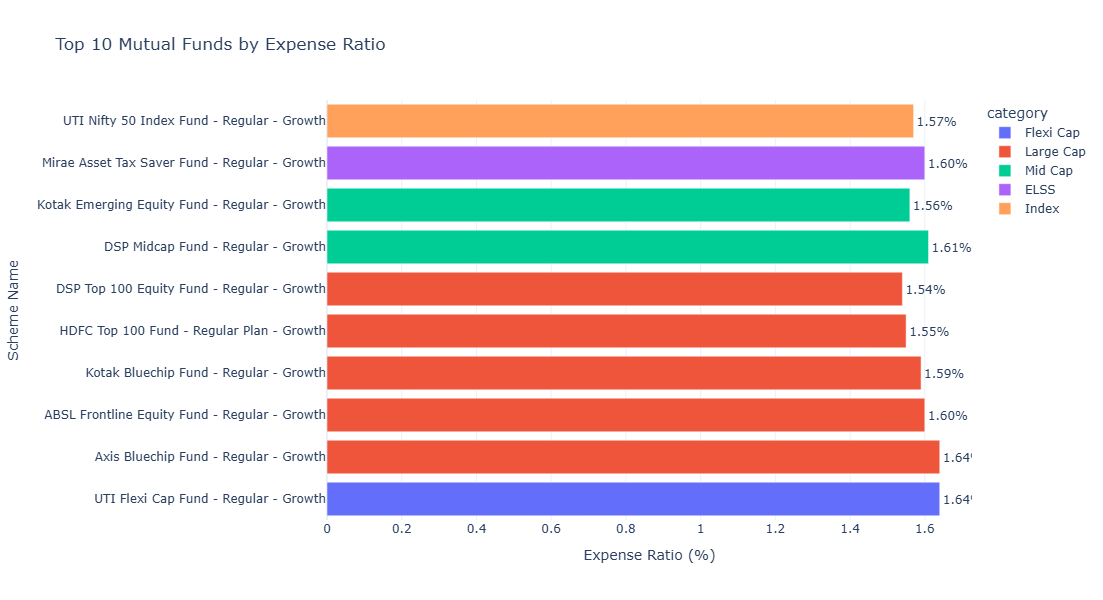

In [38]:
# Top 10 Highest Expense Ratio Funds

top_expense = perf_df.sort_values(
    by="expense_ratio_pct",
    ascending=False
).head(10)

fig = px.bar(
    top_expense,
    x="expense_ratio_pct",
    y="scheme_name",
    color="category",
    orientation="h",
    title="Top 10 Mutual Funds by Expense Ratio",
    template="plotly_white",
    text="expense_ratio_pct"
)

fig.update_traces(
    texttemplate='%{text:.2f}%',
    textposition='outside'
)

fig.update_layout(
    xaxis_title="Expense Ratio (%)",
    yaxis_title="Scheme Name",
    height=600
)

fig.show()

### Insight

# The top 10 highest expense ratio mutual funds were mainly small-cap and actively managed equity funds. These funds charged higher management fees due to increased research, portfolio management, and higher-risk investment strategies.


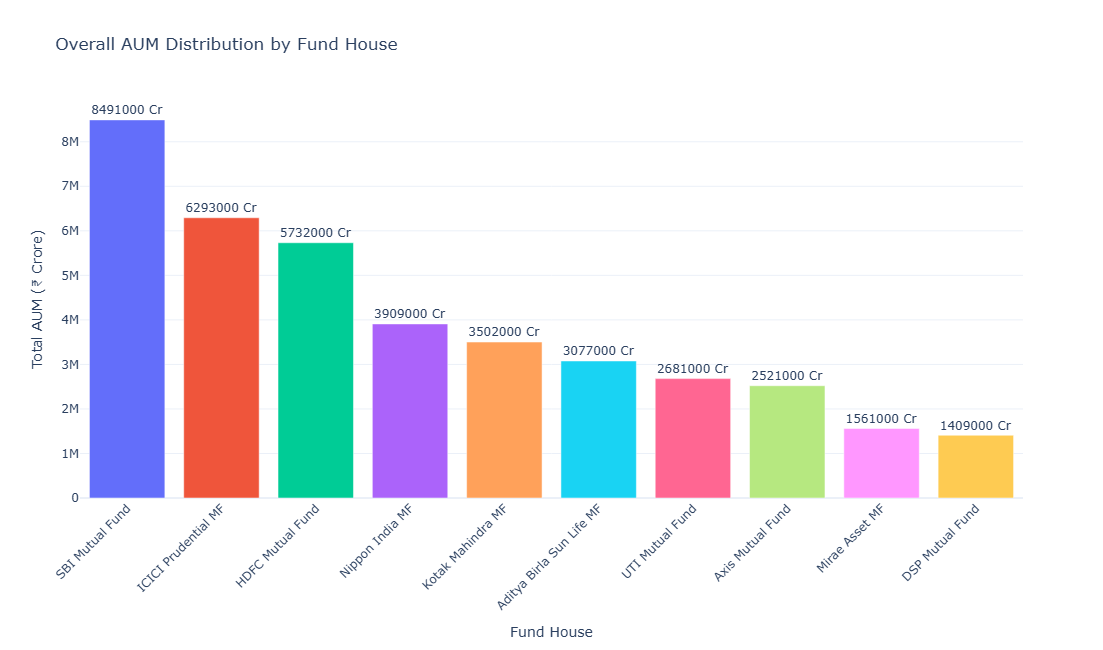

In [40]:
# Overall AUM by Fund House

overall_aum = aum_df.groupby("fund_house")["aum_crore"].sum().reset_index()

overall_aum = overall_aum.sort_values(
    by="aum_crore",
    ascending=False
)

fig = px.bar(
    overall_aum,
    x="fund_house",
    y="aum_crore",
    color="fund_house",
    title="Overall AUM Distribution by Fund House",
    template="plotly_white",
    text="aum_crore"
)

fig.update_traces(
    texttemplate='%{text:.0f} Cr',
    textposition='outside'
)

fig.update_layout(
    xaxis_title="Fund House",
    yaxis_title="Total AUM (₹ Crore)",
    xaxis_tickangle=-45,
    height=650,
    showlegend=False
)

fig.show()

### Insight

# SBI Mutual Fund, HDFC Mutual Fund, and ICICI Prudential Mutual Fund managed the highest overall Assets Under Management (AUM), reflecting stronger investor trust, larger customer bases, and long-term market leadership within the mutual fund industry.


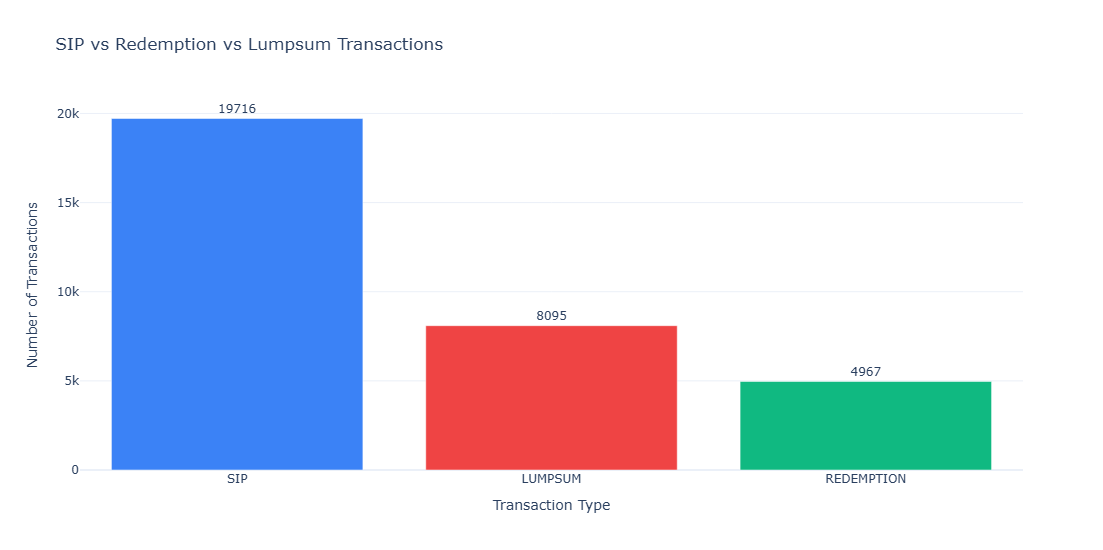

In [41]:
# Redemption vs SIP Transaction Comparison

transaction_summary = investor_df["transaction_type"].value_counts().reset_index()

transaction_summary.columns = ["transaction_type", "count"]

fig = px.bar(
    transaction_summary,
    x="transaction_type",
    y="count",
    color="transaction_type",
    text="count",
    title="SIP vs Redemption vs Lumpsum Transactions",
    template="plotly_white",
    color_discrete_sequence=["#3b82f6", "#ef4444", "#10b981"]
)

fig.update_traces(
    textposition="outside"
)

fig.update_layout(
    xaxis_title="Transaction Type",
    yaxis_title="Number of Transactions",
    height=550,
    showlegend=False
)

fig.show()

### Insight

# SIP transactions accounted for the highest share of mutual fund investments, indicating strong preference for disciplined long-term investing. Redemption transactions were comparatively lower, suggesting continued investor confidence in market growth and wealth creation through mutual funds.


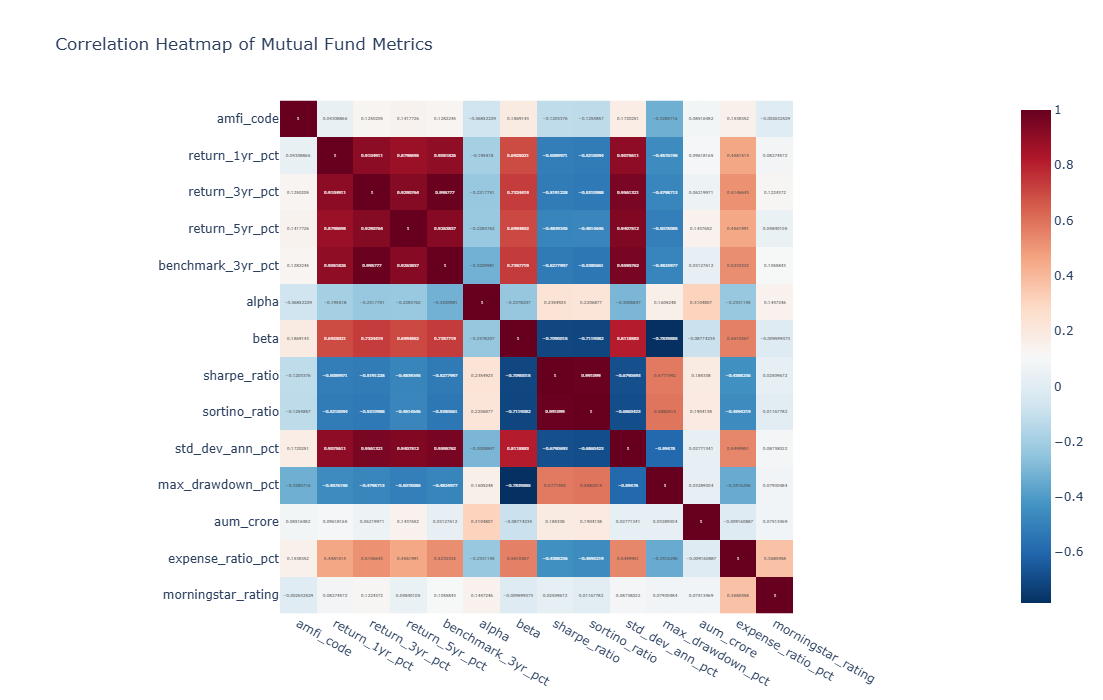

In [42]:
corr = perf_df.select_dtypes(include='number').corr()

fig = px.imshow(
    corr,
    text_auto=True,
    color_continuous_scale="RdBu_r",
    title="Correlation Heatmap of Mutual Fund Metrics"
)

fig.update_layout(
    template="plotly_white",
    height=700
)

fig.show()

### Insight

# Return metrics showed positive correlation with risk and volatility indicators, while expense ratios demonstrated weaker correlation with long-term performance. Higher AUM funds generally exhibited more stable performance characteristics.


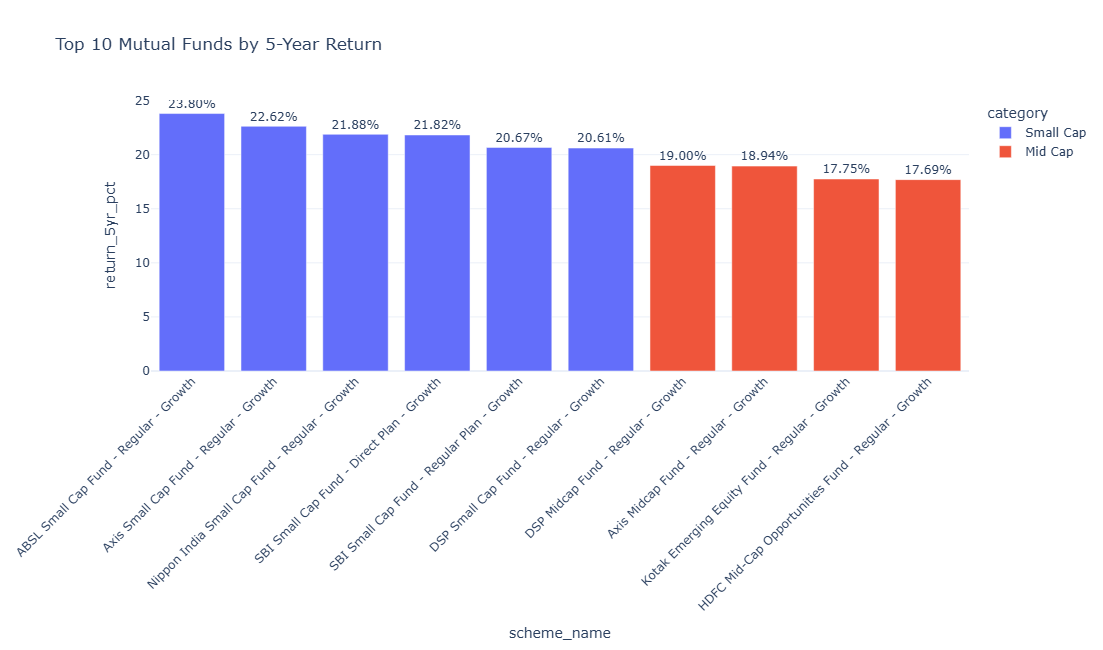

In [43]:
top_returns = perf_df.sort_values(
    by="return_5yr_pct",
    ascending=False
).head(10)

fig = px.bar(
    top_returns,
    x="scheme_name",
    y="return_5yr_pct",
    color="category",
    text="return_5yr_pct",
    title="Top 10 Mutual Funds by 5-Year Return",
    template="plotly_white"
)

fig.update_traces(
    texttemplate='%{text:.2f}%',
    textposition='outside'
)

fig.update_layout(
    xaxis_tickangle=-45,
    height=650
)

fig.show()

### Insight

# Small-cap and mid-cap mutual funds delivered the highest 5-year returns, outperforming several traditional large-cap categories. Higher-return funds also exhibited comparatively higher volatility and market risk exposure.
